# Final Evaluation - XGBoost

This notebook evaluates the final XGBoost model on the held-out August test set. Hyperparameters are fixed from Notebook 01 and are not changed here.


## 1. Setup

Imports, paths, metric helper and fixed XGBoost parameters.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor


def evaluate_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


xgboost_params = {
    "n_estimators": 200,
    "max_depth": 2,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

pd.set_option("display.max_columns", 60)

PROJECT_DIR = Path.cwd()
while not (PROJECT_DIR / "datasets").exists():
    if PROJECT_DIR == PROJECT_DIR.parent:
        raise FileNotFoundError("Project directory with datasets/ was not found.")
    PROJECT_DIR = PROJECT_DIR.parent

FEATURE_DIR = PROJECT_DIR / "datasets" / "modeling" / "features"
TRAIN_PATH = FEATURE_DIR / "train_features.parquet"
VALIDATION_PATH = FEATURE_DIR / "validation_features.parquet"
TEST_PATH = FEATURE_DIR / "test_features.parquet"


## 2. Data

The final training set combines November 2025 to July 2026. August is used only once as the final test set.


In [2]:
train = pd.read_parquet(TRAIN_PATH)
validation = pd.read_parquet(VALIDATION_PATH)
test = pd.read_parquet(TEST_PATH)

final_train = pd.concat([train, validation], ignore_index=True)

pd.DataFrame(
    [
        {"Dataset": "Final training", "Period": "Nov 2025 - Jul 2026", "Rows": len(final_train)},
        {"Dataset": "Test", "Period": "Aug 2026", "Rows": len(test)},
    ]
)


,Dataset,Period,Rows
0,Final training,Nov 2025 - Jul 2026,763551
1,Test,Aug 2026,85799


## 3. Features and preprocessing

The feature set and preprocessing match Notebook 01. The preprocessor is fitted again only on the final training set.


In [3]:
target_column = "delay_target"

categorical_features = [
    "event_hour",
    "event_weekday",
    "rr_precipitation_form",
]

numeric_features = [
    "is_public_holiday",
    "ff_wind_speed_ms",
    "wind_direction_sin",
    "wind_direction_cos",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
    "rr_precipitation_indicator",
]

model_features = categorical_features + numeric_features

y_final_train = final_train[target_column]
y_test = test[target_column]

X_final_train = final_train[model_features].copy()
X_test = test[model_features].copy()


def prepare_sklearn_features(X):
    X_prepared = X[model_features].copy()
    for column in categorical_features:
        X_prepared[column] = X_prepared[column].fillna("missing").astype(str)
    return X_prepared


X_final_train_sklearn = prepare_sklearn_features(X_final_train)
X_test_sklearn = prepare_sklearn_features(X_test)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_final_train_processed = preprocessor.fit_transform(X_final_train_sklearn)
X_test_processed = preprocessor.transform(X_test_sklearn)

# Random Forest is not used here; dense matrices are unnecessary for the final XGBoost model.
print(f"Final training rows: {X_final_train_processed.shape[0]}")
print(f"Test rows: {X_test_processed.shape[0]}")
print(f"Transformed features: {X_final_train_processed.shape[1]}")


Final training rows: 763551
Test rows: 85799
Transformed features: 46


## 4. Baselines

Median and mean baselines are fitted only on the final training target and evaluated on August.


In [4]:
median_prediction = y_final_train.median()
mean_prediction = y_final_train.mean()

median_test_predictions = np.full(len(y_test), median_prediction)
mean_test_predictions = np.full(len(y_test), mean_prediction)

baseline_results = pd.DataFrame(
    [
        {"Model": "Median Baseline", **evaluate_predictions(y_test, median_test_predictions)},
        {"Model": "Mean Baseline", **evaluate_predictions(y_test, mean_test_predictions)},
    ]
)

baseline_results.round(6)


,Model,MAE,RMSE,R2
0,Median Baseline,5.087460,10.170666,-0.148990
1,Mean Baseline,5.889041,9.489514,-0.000243


## 5. Final XGBoost training

The selected XGBoost configuration is trained on the combined November to July data and then evaluated on August.


In [5]:
final_xgboost_model = XGBRegressor(**xgboost_params)
final_xgboost_model.fit(X_final_train_processed, y_final_train)

test_predictions = final_xgboost_model.predict(X_test_processed)
xgboost_test_metrics = evaluate_predictions(y_test, test_predictions)

model_comparison = pd.concat(
    [baseline_results, pd.DataFrame([{ "Model": "XGBoost", **xgboost_test_metrics }])],
    ignore_index=True,
).sort_values("R2", ascending=False).reset_index(drop=True)

model_comparison.round(6)


,Model,MAE,RMSE,R2
0,XGBoost,6.064142,9.467418,0.004410
1,Mean Baseline,5.889041,9.489514,-0.000243
2,Median Baseline,5.087460,10.170666,-0.148990


## 6. Prediction distribution diagnostics

These diagnostics check whether the visible horizontal bands in the scatterplot come from the prediction distribution itself. They do not change the model, the preprocessing or the metrics.


In [6]:
pred = pd.Series(test_predictions, name="prediction")

prediction_summary = pd.DataFrame(
    [
        {
            "Minimum": pred.min(),
            "Maximum": pred.max(),
            "Exact unique predictions": pred.nunique(),
            "Unique predictions rounded to 2 decimals": pred.round(2).nunique(),
            "Unique predictions rounded to 1 decimal": pred.round(1).nunique(),
        }
    ]
)

print("Prediction summary")
display(prediction_summary.round(6))

print("Predictions rounded to 1 decimal")
print(pred.round(1).value_counts().sort_index().to_string())

print("Predictions between 9 and 13 minutes, rounded to 2 decimals")
print(
    pred[(pred >= 9) & (pred <= 13)]
    .round(2)
    .value_counts()
    .sort_index()
    .to_string()
)


Prediction summary


,Minimum,Maximum,Exact unique predictions,Unique predictions rounded to 2 decimals,Unique predictions rounded to 1 decimal
0,1.799466,14.184067,1448,580,98


Predictions rounded to 1 decimal
prediction
1.8        4
2.0        6
2.1       84
2.2       26
2.3       29
2.4       93
2.5        4
2.6       34
2.7      122
2.8      114
2.9      124
3.0       85
3.1      216
3.2      143
3.3      123
3.4      604
3.5      393
3.6      668
3.7     1576
3.8      633
3.9      830
4.0      968
4.1      762
4.2     1183
4.3     1898
4.4     1399
4.5     1197
4.6      658
4.7      830
4.8     1454
4.9     1257
5.0     1588
5.1     2250
5.2     2230
5.3     2426
5.4     2781
5.5     3529
5.6     2628
5.7     2592
5.8     3925
5.9     2895
6.0     2100
6.1     3793
6.2     1503
6.3     3001
6.4     1853
6.5     1781
6.6     3158
6.7      845
6.8     1940
6.9     2342
7.0      608
7.1      880
7.2     1737
7.3     1442
7.4     1005
7.5      985
7.6      530
7.7      805
7.8      622
7.9      738
8.0      193
8.1      539
8.2      400
8.3      115
8.4      565
8.5      294
8.6      297
8.7      549
8.8      240
8.9     1691
9.0      267
9.1      449
9.2    

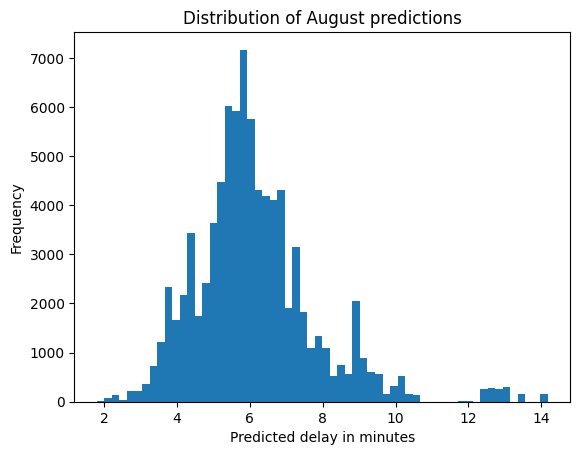

In [7]:
plt.hist(test_predictions, bins=60)
plt.xlabel("Predicted delay in minutes")
plt.ylabel("Frequency")
plt.title("Distribution of August predictions")
plt.show()


## 7. Duplicate raw feature vectors

The model only sees the external features listed in `model_features`. Identical raw feature vectors must therefore receive identical predictions.


In [8]:
total_rows = len(X_test)
unique_feature_rows = X_test[model_features].drop_duplicates().shape[0]
duplicate_share = 1 - unique_feature_rows / total_rows

feature_vector_summary = pd.DataFrame(
    [
        {
            "Total test rows": total_rows,
            "Unique raw feature rows": unique_feature_rows,
            "Duplicate feature-vector share": duplicate_share,
        }
    ]
)

display(feature_vector_summary.round(6))

print("10 most frequent complete raw feature combinations")
display(X_test[model_features].value_counts(dropna=False).head(10).reset_index(name="count"))


,Total test rows,Unique raw feature rows,Duplicate feature-vector share
0,85799,2131,0.975163


10 most frequent complete raw feature combinations


,event_hour,event_weekday,rr_precipitation_form,is_public_holiday,ff_wind_speed_ms,wind_direction_sin,wind_direction_cos,fx_wind_gust_ms,tu_temperature_c,tu_relative_humidity_pct,rr_precipitation_mm,rr_precipitation_indicator,count
0,7,3,0.0,False,2.8,7.660444e-01,-6.427876e-01,3.6,14.3,56.0,0.0,0.0,151
1,7,0,6.0,False,0.8,-1.000000e+00,-1.836970e-16,2.5,14.6,91.0,0.3,1.0,150
2,9,2,0.0,False,2.5,1.224647e-16,-1.000000e+00,3.8,18.9,83.0,0.0,0.0,146
3,14,2,0.0,False,4.0,8.660254e-01,-5.000000e-01,7.1,22.9,60.0,0.0,0.0,146
4,7,2,0.0,False,3.4,1.224647e-16,-1.000000e+00,4.4,18.1,92.0,0.0,0.0,146
5,7,1,6.0,False,2.3,7.660444e-01,-6.427876e-01,3.8,15.4,92.0,0.3,1.0,146
6,14,2,0.0,False,3.4,9.848078e-01,1.736482e-01,8.9,28.5,23.0,0.0,0.0,145
7,16,4,0.0,False,1.7,-6.427876e-01,-7.660444e-01,4.3,21.9,50.0,0.0,0.0,145
8,19,2,0.0,False,3.4,9.848078e-01,-1.736482e-01,7.2,31.5,19.0,0.0,0.0,145
9,9,1,6.0,False,3.0,6.427876e-01,-7.660444e-01,4.5,15.7,94.0,2.4,1.0,145


In [9]:
feature_target_prediction_data = X_test[model_features].copy()
feature_target_prediction_data["actual_delay"] = y_test.to_numpy()
feature_target_prediction_data["prediction"] = test_predictions

feature_group_spread = (
    feature_target_prediction_data
    .groupby(model_features, dropna=False)
    .agg(
        count=("actual_delay", "size"),
        mean_actual_delay=("actual_delay", "mean"),
        std_actual_delay=("actual_delay", "std"),
        min_actual_delay=("actual_delay", "min"),
        max_actual_delay=("actual_delay", "max"),
        mean_prediction=("prediction", "mean"),
    )
    .reset_index()
)

largest_duplicate_feature_groups = (
    feature_group_spread[feature_group_spread["count"] > 1]
    .sort_values("count", ascending=False)
    .head(10)
)

largest_duplicate_feature_groups.round(3)


,event_hour,event_weekday,rr_precipitation_form,is_public_holiday,ff_wind_speed_ms,wind_direction_sin,wind_direction_cos,fx_wind_gust_ms,tu_temperature_c,tu_relative_humidity_pct,rr_precipitation_mm,rr_precipitation_indicator,count,mean_actual_delay,std_actual_delay,min_actual_delay,max_actual_delay,mean_prediction
606,7,3,0.0,False,2.8,0.766,-0.643,3.6,14.3,56.0,0.0,0.0,151,5.907,8.827,0.0,46.0,5.656
571,7,0,6.0,False,0.8,-1.000,-0.000,2.5,14.6,91.0,0.3,1.0,150,3.840,4.504,0.0,18.0,4.496
1242,14,2,0.0,False,4.0,0.866,-0.500,7.1,22.9,60.0,0.0,0.0,146,6.603,10.070,0.0,53.0,6.085
776,9,2,0.0,False,2.5,0.000,-1.000,3.8,18.9,83.0,0.0,0.0,146,3.363,4.706,0.0,35.0,5.465
594,7,2,0.0,False,3.4,0.000,-1.000,4.4,18.1,92.0,0.0,0.0,146,2.726,4.482,0.0,31.0,5.467
584,7,1,6.0,False,2.3,0.766,-0.643,3.8,15.4,92.0,0.3,1.0,146,4.308,5.653,0.0,36.0,5.437
507,6,2,0.0,False,3.3,0.000,-1.000,4.5,17.7,94.0,0.0,0.0,145,2.862,9.530,0.0,78.0,4.967
1325,15,1,6.0,False,5.2,-0.985,-0.174,10.3,18.7,88.0,0.0,1.0,145,4.462,6.047,0.0,34.0,5.584
767,9,1,6.0,False,3.0,0.643,-0.766,4.5,15.7,94.0,2.4,1.0,145,5.517,9.057,0.0,46.0,5.640
1445,16,4,0.0,False,1.7,-0.643,-0.766,4.3,21.9,50.0,0.0,0.0,145,7.641,10.355,0.0,55.0,6.902


In [10]:
prediction_bins = pd.cut(
    pred,
    bins=np.arange(
        np.floor(pred.min()),
        np.ceil(pred.max()) + 0.5,
        0.5,
    ),
)

prediction_bin_counts = pred.groupby(prediction_bins, observed=False).size()
print(prediction_bin_counts.to_string())


prediction
(1.0, 1.5]          0
(1.5, 2.0]         10
(2.0, 2.5]        236
(2.5, 3.0]        394
(3.0, 3.5]       1331
(3.5, 4.0]       4541
(4.0, 4.5]       6293
(4.5, 5.0]       5642
(5.0, 5.5]      12237
(5.5, 6.0]      14517
(6.0, 6.5]      12536
(6.5, 7.0]       9224
(7.0, 7.5]       5856
(7.5, 8.0]       3242
(8.0, 8.5]       1895
(8.5, 9.0]       3069
(9.0, 9.5]       1517
(9.5, 10.0]       758
(10.0, 10.5]      927
(10.5, 11.0]      138
(11.0, 11.5]        0
(11.5, 12.0]       20
(12.0, 12.5]      141
(12.5, 13.0]      810
(13.0, 13.5]      308
(13.5, 14.0]        0
(14.0, 14.5]      157
(14.5, 15.0]        0


## 8. Train vs. August

This checks how the final XGBoost model behaves on its final training data compared with the held-out August test set.


In [11]:
train_predictions = final_xgboost_model.predict(X_final_train_processed)
train_metrics = evaluate_predictions(y_final_train, train_predictions)

generalization_comparison = pd.DataFrame(
    [
        {"Dataset": "Final training", **train_metrics},
        {"Dataset": "August test", **xgboost_test_metrics},
    ]
)

generalization_comparison.round(6)


,Dataset,MAE,RMSE,R2
0,Final training,5.753054,9.943276,0.027521
1,August test,6.064142,9.467418,0.004410


## 9. Error diagnostics

All metrics are calculated on the full August test set. The plot only limits the visible range to avoid one extreme delay dominating the axis.


In [12]:
residuals = y_test - test_predictions
absolute_errors = np.abs(residuals)

residual_summary = pd.DataFrame(
    [
        {
            "Mean residual": residuals.mean(),
            "Median residual": residuals.median(),
            "MAE": mean_absolute_error(y_test, test_predictions),
            "Median absolute error": median_absolute_error(y_test, test_predictions),
            "95% absolute error": np.quantile(absolute_errors, 0.95),
            "Max absolute error": absolute_errors.max(),
        }
    ]
)

residual_summary.round(3)


,Mean residual,Median residual,MAE,Median absolute error,95% absolute error,Max absolute error
0,-0.471,-3.474,6.064,4.674,16.968,215.17


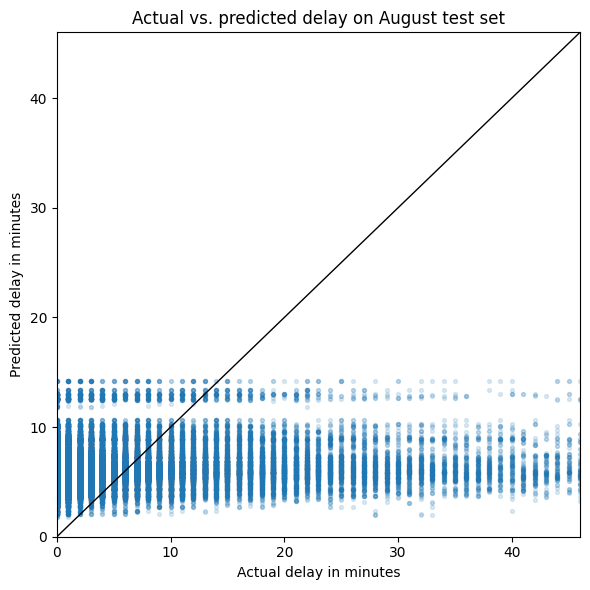

In [13]:
plot_limit = max(y_test.quantile(0.99), np.quantile(test_predictions, 0.99))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, test_predictions, alpha=0.15, s=8)
ax.plot([0, plot_limit], [0, plot_limit], color="black", linewidth=1)
ax.set_xlim(0, plot_limit)
ax.set_ylim(0, plot_limit)
ax.set_xlabel("Actual delay in minutes")
ax.set_ylabel("Predicted delay in minutes")
ax.set_title("Actual vs. predicted delay on August test set")
plt.tight_layout()
plt.show()


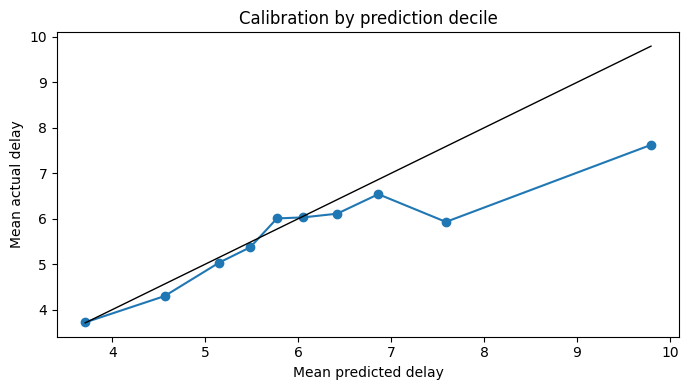

,mean_prediction,mean_actual,observations
0,3.709,3.719,8818
1,4.563,4.298,8459
2,5.152,5.037,8486
3,5.484,5.372,8575
4,5.772,6.006,8650
5,6.058,6.030,8493
6,6.419,6.111,8868
7,6.863,6.540,8412
8,7.590,5.930,8509
9,9.796,7.624,8529


In [14]:
calibration_data = pd.DataFrame(
    {
        "actual": y_test.to_numpy(),
        "prediction": test_predictions,
    }
)
calibration_data["prediction_bin"] = pd.qcut(
    calibration_data["prediction"],
    q=10,
    duplicates="drop",
)

calibration_summary = (
    calibration_data.groupby("prediction_bin", observed=True)
    .agg(
        mean_prediction=("prediction", "mean"),
        mean_actual=("actual", "mean"),
        observations=("actual", "size"),
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(calibration_summary["mean_prediction"], calibration_summary["mean_actual"], marker="o")
ax.plot(
    [calibration_summary["mean_prediction"].min(), calibration_summary["mean_prediction"].max()],
    [calibration_summary["mean_prediction"].min(), calibration_summary["mean_prediction"].max()],
    color="black",
    linewidth=1,
)
ax.set_xlabel("Mean predicted delay")
ax.set_ylabel("Mean actual delay")
ax.set_title("Calibration by prediction decile")
plt.tight_layout()
plt.show()

calibration_summary.round(3)


## 10. Post-hoc stability analysis

The following August analyses happen after the final evaluation. They are diagnostics only and are not used to change model parameters, features or model selection.


In [15]:
def predict_xgboost(X):
    return final_xgboost_model.predict(preprocessor.transform(prepare_sklearn_features(X)))


def grouped_permutation_importance(X, y, groups, repeats=5, random_state=42):
    rng = np.random.default_rng(random_state)
    baseline_r2 = r2_score(y, predict_xgboost(X))
    rows = []

    for group_name, columns in groups.items():
        unique_counts = X[columns].nunique(dropna=False)
        if (unique_counts <= 1).all():
            rows.append(
                {
                    "Feature group": group_name,
                    "Columns": ", ".join(columns),
                    "Baseline R2": baseline_r2,
                    "Mean permuted R2": np.nan,
                    "Importance": np.nan,
                    "Std importance": np.nan,
                    "Status": "constant",
                }
            )
            continue

        importances = []
        permuted_scores = []
        for _ in range(repeats):
            permuted = X.copy()
            order = rng.permutation(len(permuted))
            permuted.loc[:, columns] = X.loc[:, columns].iloc[order].to_numpy()
            permuted_r2 = r2_score(y, predict_xgboost(permuted))
            permuted_scores.append(permuted_r2)
            importances.append(baseline_r2 - permuted_r2)

        rows.append(
            {
                "Feature group": group_name,
                "Columns": ", ".join(columns),
                "Baseline R2": baseline_r2,
                "Mean permuted R2": np.mean(permuted_scores),
                "Importance": np.mean(importances),
                "Std importance": np.std(importances),
                "Status": "ok",
            }
        )

    return pd.DataFrame(rows).sort_values("Importance", ascending=False).reset_index(drop=True)


importance_groups = {
    "Tageszeit": ["event_hour"],
    "Wochentag": ["event_weekday"],
    "Feiertag": ["is_public_holiday"],
    "Temperatur": ["tu_temperature_c"],
    "Relative Luftfeuchtigkeit": ["tu_relative_humidity_pct"],
    "Windgeschwindigkeit": ["ff_wind_speed_ms"],
    "Windrichtung": ["wind_direction_sin", "wind_direction_cos"],
    "Windboeen": ["fx_wind_gust_ms"],
    "Niederschlagsmenge": ["rr_precipitation_mm"],
    "Niederschlagsindikator": ["rr_precipitation_indicator"],
    "Niederschlagsform": ["rr_precipitation_form"],
    "Niederschlag gesamt": [
        "rr_precipitation_mm",
        "rr_precipitation_indicator",
        "rr_precipitation_form",
    ],
}

august_permutation_importance = grouped_permutation_importance(
    X_test,
    y_test,
    importance_groups,
    repeats=5,
    random_state=42,
)

august_permutation_importance.round(6)


,Feature group,Columns,Baseline R2,Mean permuted R2,Importance,Std importance,Status
0,Wochentag,event_weekday,0.00441,-0.007766,0.012176,0.000444,ok
1,Temperatur,tu_temperature_c,0.00441,-0.007394,0.011804,0.001041,ok
2,Tageszeit,event_hour,0.00441,-0.002292,0.006703,0.000365,ok
3,Windrichtung,"wind_direction_sin, wind_direction_cos",0.00441,0.003296,0.001114,0.000084,ok
4,Niederschlag gesamt,"rr_precipitation_mm, rr_precipitation_indicato...",0.00441,0.003406,0.001004,0.000078,ok
5,Niederschlagsmenge,rr_precipitation_mm,0.00441,0.003592,0.000818,0.000139,ok
6,Relative Luftfeuchtigkeit,tu_relative_humidity_pct,0.00441,0.003721,0.000689,0.000071,ok
7,Windboeen,fx_wind_gust_ms,0.00441,0.003847,0.000563,0.000071,ok
8,Niederschlagsform,rr_precipitation_form,0.00441,0.004297,0.000113,0.000010,ok
9,Windgeschwindigkeit,ff_wind_speed_ms,0.00441,0.004424,-0.000014,0.000053,ok


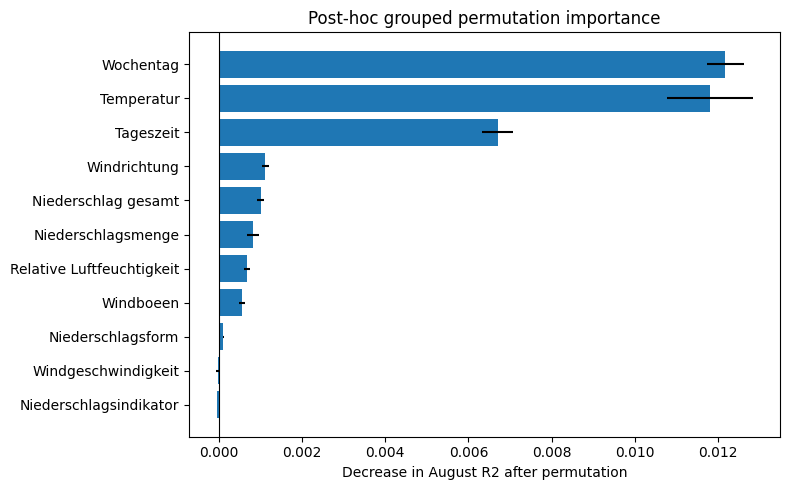

In [16]:
plot_data = august_permutation_importance.dropna(subset=["Importance"]).sort_values("Importance")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_data["Feature group"], plot_data["Importance"], xerr=plot_data["Std importance"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Decrease in August R2 after permutation")
ax.set_title("Post-hoc grouped permutation importance")
plt.tight_layout()
plt.show()


## 11. Post-hoc partial dependence on August

Only the central features are shown here to avoid duplicating the broader interpretation notebook.


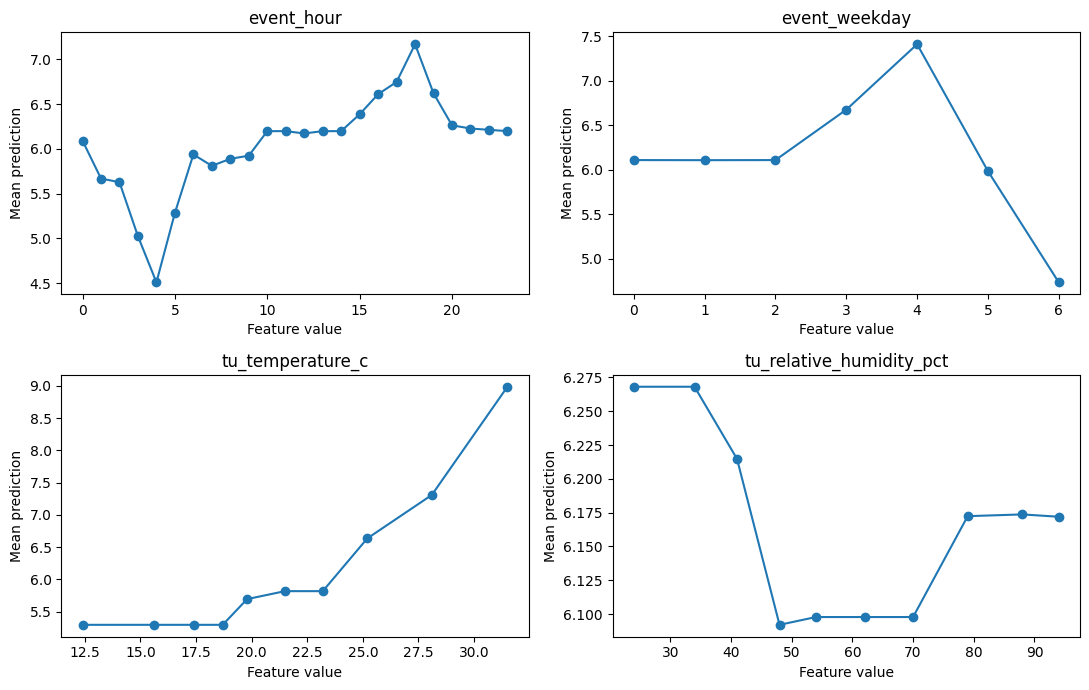

,Feature,Value,Mean prediction
0,event_hour,0.0,6.091
1,event_hour,1.0,5.668
2,event_hour,2.0,5.627
3,event_hour,3.0,5.024
4,event_hour,4.0,4.509
5,event_hour,5.0,5.284
6,event_hour,6.0,5.937
7,event_hour,7.0,5.810
8,event_hour,8.0,5.889
9,event_hour,9.0,5.923


In [17]:
def numeric_grid(series, points=10):
    values = pd.to_numeric(series, errors="coerce").dropna()
    return sorted(set(float(value) for value in np.quantile(values, np.linspace(0.05, 0.95, points))))


def numeric_partial_dependence(X, feature, values):
    rows = []
    for value in values:
        changed = X.copy()
        changed[feature] = value
        rows.append({"Feature": feature, "Value": value, "Mean prediction": predict_xgboost(changed).mean()})
    return pd.DataFrame(rows)


def categorical_partial_dependence(X, feature, values):
    rows = []
    for value in values:
        changed = X.copy()
        changed[feature] = value
        rows.append({"Feature": feature, "Value": value, "Mean prediction": predict_xgboost(changed).mean()})
    return pd.DataFrame(rows)


pdp_results = {
    "event_hour": categorical_partial_dependence(
        X_test,
        "event_hour",
        sorted(X_test["event_hour"].dropna().unique()),
    ),
    "event_weekday": categorical_partial_dependence(
        X_test,
        "event_weekday",
        sorted(X_test["event_weekday"].dropna().unique()),
    ),
    "tu_temperature_c": numeric_partial_dependence(
        X_test,
        "tu_temperature_c",
        numeric_grid(X_test["tu_temperature_c"]),
    ),
    "tu_relative_humidity_pct": numeric_partial_dependence(
        X_test,
        "tu_relative_humidity_pct",
        numeric_grid(X_test["tu_relative_humidity_pct"]),
    ),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

for ax, feature in zip(axes, pdp_results):
    data = pdp_results[feature]
    ax.plot(data["Value"], data["Mean prediction"], marker="o")
    ax.set_title(feature)
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Mean prediction")

plt.tight_layout()
plt.show()

pd.concat(pdp_results.values(), ignore_index=True).head(20).round(3)


## 12. Short final statement

The August metrics above are the final out-of-sample evaluation of the fixed XGBoost model. The post-hoc diagnostics describe model behavior on August but do not feed back into the model.


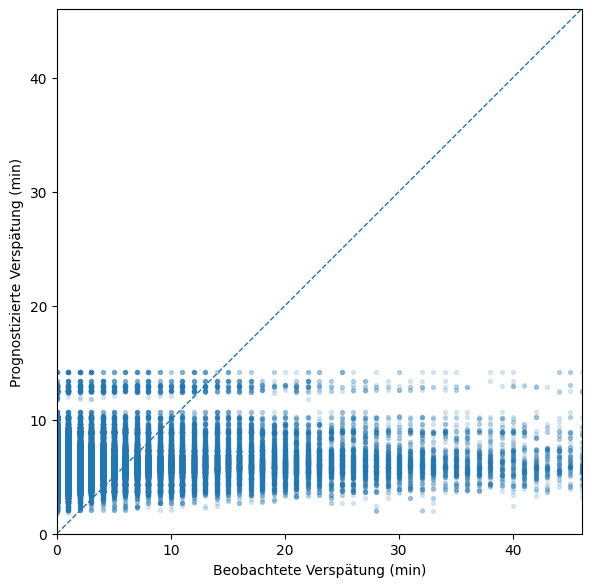

In [18]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

export_dir = PROJECT_DIR / "outputs" / "final_evaluation"
export_dir.mkdir(parents=True, exist_ok=True)

plot_limit = max(
    y_test.quantile(0.99),
    np.quantile(test_predictions, 0.99)
)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    y_test,
    test_predictions,
    alpha=0.15,
    s=8
)

ax.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    linewidth=1
)

ax.set_xlim(0, plot_limit)
ax.set_ylim(0, plot_limit)

ax.set_xlabel("Beobachtete Verspätung (min)")
ax.set_ylabel("Prognostizierte Verspätung (min)")
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

fig.savefig(
    export_dir / "ist_prognose_august.pdf",
    bbox_inches="tight"
)
fig.savefig(
    export_dir / "ist_prognose_august.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()